In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO

In [16]:
data = """order_id,distance_miles,traffic_level,time_of_day,driver_experience_years,weather,delivery_time_minutes,is_delayed
1,5,High,Morning,2,Rain,45,1
2,2,Low,Afternoon,5,Clear,20,0
3,8,High,Evening,1,Rain,60,1
4,3,Medium,Morning,3,Clear,25,0
5,10,High,Evening,2,Fog,70,1
6,1,Low,Afternoon,4,Clear,15,0
7,6,Medium,Evening,2,Rain,50,1
8,4,Low,Morning,6,Clear,22,0
9,7,High,Afternoon,1,Rain,65,1
10,3,Medium,Evening,3,Clear,30,0
11,9,High,Morning,2,Fog,75,1
12,2,Low,Afternoon,5,Clear,18,0
13,5,Medium,Evening,4,Rain,40,1
14,6,High,Evening,1,Fog,68,1
15,3,Low,Morning,6,Clear,20,0"""

df = pd.read_csv(StringIO(data))

df.head()


,order_id,distance_miles,traffic_level,time_of_day,driver_experience_years,weather,delivery_time_minutes,is_delayed
0,1,5,High,Morning,2,Rain,45,1
1,2,2,Low,Afternoon,5,Clear,20,0
2,3,8,High,Evening,1,Rain,60,1
3,4,3,Medium,Morning,3,Clear,25,0
4,5,10,High,Evening,2,Fog,70,1


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   order_id                 15 non-null     int64 
 1   distance_miles           15 non-null     int64 
 2   traffic_level            15 non-null     object
 3   time_of_day              15 non-null     object
 4   driver_experience_years  15 non-null     int64 
 5   weather                  15 non-null     object
 6   delivery_time_minutes    15 non-null     int64 
 7   is_delayed               15 non-null     int64 
dtypes: int64(5), object(3)
memory usage: 1.1+ KB


,order_id,distance_miles,driver_experience_years,delivery_time_minutes,is_delayed
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,8.000000,4.933333,3.133333,41.533333,0.533333
std,4.472136,2.711527,1.767430,21.682339,0.516398
min,1.000000,1.000000,1.000000,15.000000,0.000000
25%,4.500000,3.000000,2.000000,21.000000,0.000000
50%,8.000000,5.000000,3.000000,40.000000,1.000000
75%,11.500000,6.500000,4.500000,62.500000,1.000000
max,15.000000,10.000000,6.000000,75.000000,1.000000


In [18]:
df.groupby('traffic_level')['is_delayed'].mean()

traffic_level
High      1.0
Low       0.0
Medium    0.5
Name: is_delayed, dtype: float64

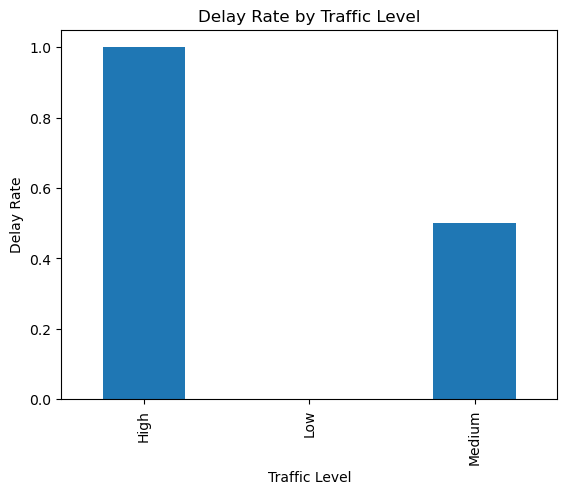

In [19]:
df.groupby('traffic_level')['is_delayed'].mean().plot(kind='bar')
plt.title("Delay Rate by Traffic Level")
plt.ylabel("Delay Rate")
plt.xlabel("Traffic Level")
plt.show()

In [20]:
df['is_rush_hour'] = df['time_of_day'].apply(lambda x: 1 if x in ['Morning', 'Evening'] else 0)

df.head()

,order_id,distance_miles,traffic_level,time_of_day,driver_experience_years,weather,delivery_time_minutes,is_delayed,is_rush_hour
0,1,5,High,Morning,2,Rain,45,1,1
1,2,2,Low,Afternoon,5,Clear,20,0,0
2,3,8,High,Evening,1,Rain,60,1,1
3,4,3,Medium,Morning,3,Clear,25,0,1
4,5,10,High,Evening,2,Fog,70,1,1


In [21]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,order_id,distance_miles,driver_experience_years,delivery_time_minutes,is_delayed,is_rush_hour,traffic_level_Low,traffic_level_Medium,time_of_day_Evening,time_of_day_Morning,weather_Fog,weather_Rain
0,1,5,2,45,1,1,False,False,False,True,False,True
1,2,2,5,20,0,0,True,False,False,False,False,False
2,3,8,1,60,1,1,False,False,True,False,False,True
3,4,3,3,25,0,1,False,True,False,True,False,False
4,5,10,2,70,1,1,False,False,True,False,True,False


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df_encoded.drop('is_delayed', axis=1)
y = df_encoded['is_delayed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.6666666666666666


In [23]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
}).sort_values(by='Importance', ascending=False)

coefficients

,Feature,Importance
3,delivery_time_minutes,0.428249
1,distance_miles,0.055100
10,weather_Rain,0.024089
8,time_of_day_Morning,0.013555
4,is_rush_hour,0.000879
9,weather_Fog,0.000079
5,traffic_level_Low,-0.001085
7,time_of_day_Evening,-0.012676
6,traffic_level_Medium,-0.017907
2,driver_experience_years,-0.026449
